# CSV Dataset Exploration

End-to-end exploratory data analysis: generate synthetic data, clean it, profile it, and visualize it.

## 1. Generate Synthetic Dataset

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 300

df_raw = pd.DataFrame({
    "age":        np.random.randint(18, 70, n).astype(float),
    "salary":     np.random.normal(55000, 15000, n).round(2),
    "department": np.random.choice(["Engineering", "Sales", "HR", "Marketing"], n),
    "years_exp":  np.random.randint(0, 30, n).astype(float),
    "score":      np.random.uniform(0, 100, n).round(1),
    "gender":     np.random.choice(["M", "F", "Other"], n, p=[0.48, 0.48, 0.04]),
})

# Inject noise: ~8% missing values and a few duplicates
for col in ["age", "salary", "score"]:
    mask = np.random.random(n) < 0.08
    df_raw.loc[mask, col] = np.nan

df_raw = pd.concat([df_raw, df_raw.sample(10, random_state=1)], ignore_index=True)

# Save to CSV so the notebook mirrors a real workflow
df_raw.to_csv("sample_dataset.csv", index=False)
print(f"Saved sample_dataset.csv — {len(df_raw)} rows, {df_raw.shape[1]} columns")

Saved sample_dataset.csv — 310 rows, 6 columns


## 2. Basic EDA

In [2]:
df = pd.read_csv("sample_dataset.csv")

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (310, 6)

Data types:
 age           float64
salary        float64
department     object
years_exp     float64
score         float64
gender         object
dtype: object

First 5 rows:


,age,salary,department,years_exp,score,gender
0,56.0,NaN,HR,24.0,14.1,F
1,69.0,57709.34,Marketing,12.0,40.6,Other
2,46.0,69472.16,HR,9.0,32.4,F
3,32.0,39027.53,HR,24.0,8.7,M
4,60.0,56630.68,HR,17.0,63.3,F


In [3]:
print("Summary statistics:")
df.describe(include="all")

Summary statistics:


,age,salary,department,years_exp,score,gender
count,291.000000,284.000000,310,310.000000,278.000000,310
unique,NaN,NaN,4,NaN,NaN,3
top,NaN,NaN,HR,NaN,NaN,F
freq,NaN,NaN,84,NaN,NaN,151
mean,43.463918,54305.668627,NaN,14.532258,51.346403,NaN
std,15.450072,16370.465228,NaN,8.849182,29.799866,NaN
min,18.000000,4538.570000,NaN,0.000000,0.000000,NaN
25%,30.000000,43241.967500,NaN,7.000000,25.925000,NaN
50%,44.000000,53835.520000,NaN,14.500000,52.100000,NaN
75%,56.000000,67613.462500,NaN,22.000000,77.100000,NaN


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print("Missing values:")
pd.DataFrame({"count": missing, "pct": missing_pct})[missing > 0]

Missing values:


,count,pct
age,19,6.13
salary,26,8.39
score,32,10.32


## 3. Data Cleaning

In [5]:
df_clean = df.copy()

# Drop duplicate rows
n_dupes = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"Removed {n_dupes} duplicate rows")

# Fill numeric nulls with median
for col in ["age", "salary", "score"]:
    median = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median)
    print(f"  {col}: filled nulls with median ({median:.2f})")

# Ensure correct types
df_clean["age"] = df_clean["age"].astype(int)
df_clean["years_exp"] = df_clean["years_exp"].astype(int)
df_clean["department"] = df_clean["department"].astype("category")
df_clean["gender"] = df_clean["gender"].astype("category")

print(f"\nClean shape: {df_clean.shape}")
df_clean.head()

Removed 10 duplicate rows
  age: filled nulls with median (43.50)
  salary: filled nulls with median (53835.52)
  score: filled nulls with median (52.10)

Clean shape: (300, 6)


,age,salary,department,years_exp,score,gender
0,56,53835.52,HR,24,14.1,F
1,69,57709.34,Marketing,12,40.6,Other
2,46,69472.16,HR,9,32.4,F
3,32,39027.53,HR,24,8.7,M
4,60,56630.68,HR,17,63.3,F


## 4. Visualizations

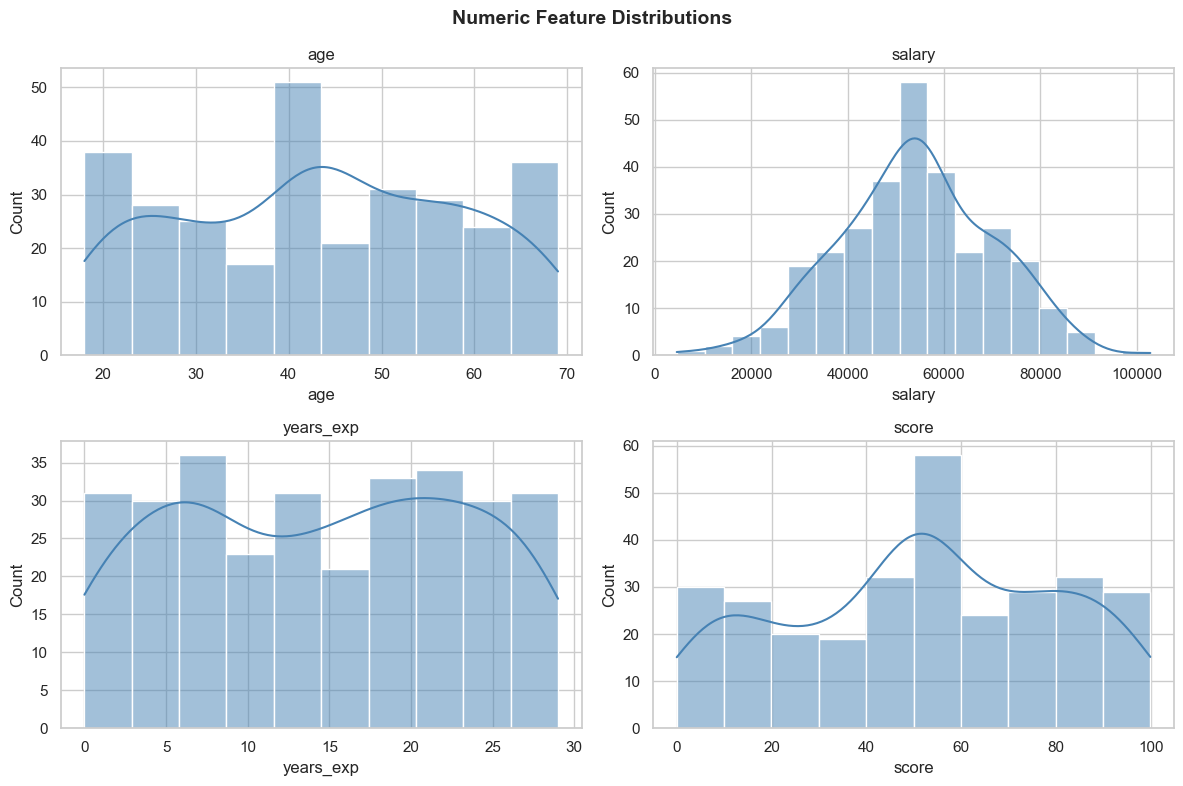

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
numeric_cols = ["age", "salary", "years_exp", "score"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df_clean[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)

plt.tight_layout()
plt.show()

C:\Users\stats\AppData\Local\Temp\ipykernel_20372\2300483876.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_counts.index, y=dept_counts.values, ax=axes[0], palette="muted")
C:\Users\stats\AppData\Local\Temp\ipykernel_20372\2300483876.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_salary.index, y=avg_salary.values, ax=axes[1], palette="coolwarm")


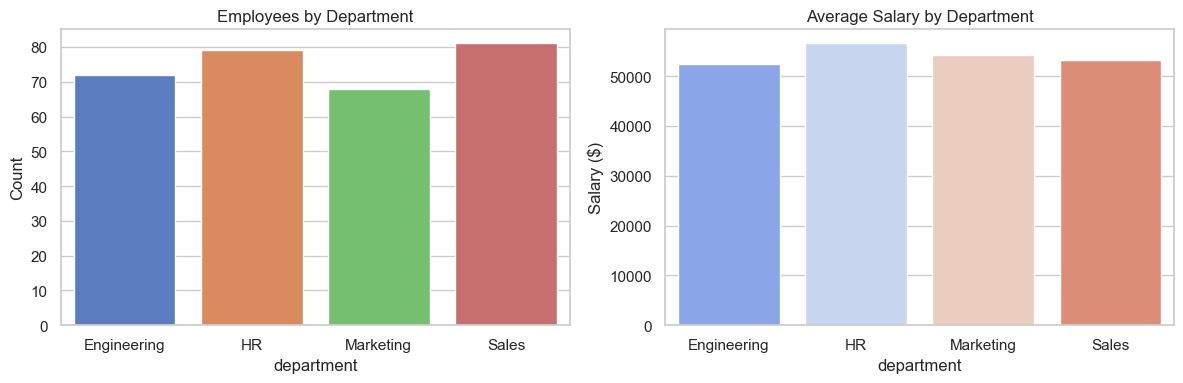

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Department counts
dept_counts = df_clean["department"].value_counts()
sns.barplot(x=dept_counts.index, y=dept_counts.values, ax=axes[0], palette="muted")
axes[0].set_title("Employees by Department")
axes[0].set_ylabel("Count")

# Average salary by department
avg_salary = df_clean.groupby("department", observed=True)["salary"].mean().sort_values(ascending=False)
sns.barplot(x=avg_salary.index, y=avg_salary.values, ax=axes[1], palette="coolwarm")
axes[1].set_title("Average Salary by Department")
axes[1].set_ylabel("Salary ($)")

plt.tight_layout()
plt.show()

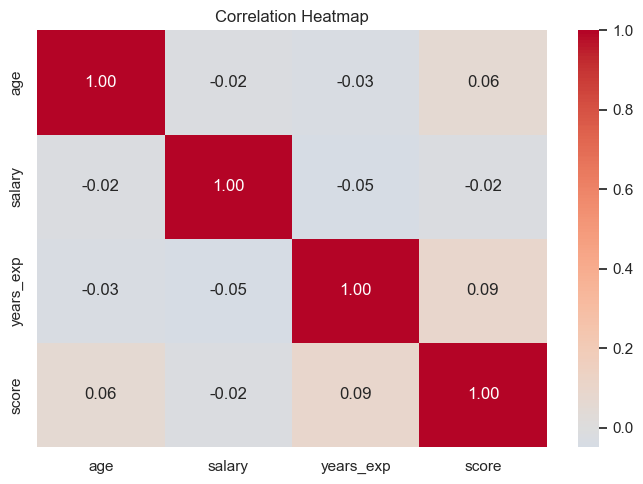

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 5. Feature Analysis

In [9]:
# Outlier detection via IQR
print("Outlier counts (IQR method):")
for col in numeric_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((df_clean[col] < Q1 - 1.5 * IQR) | (df_clean[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col}: {outliers} outliers")

Outlier counts (IQR method):
  age: 0 outliers
  salary: 3 outliers
  years_exp: 0 outliers
  score: 0 outliers


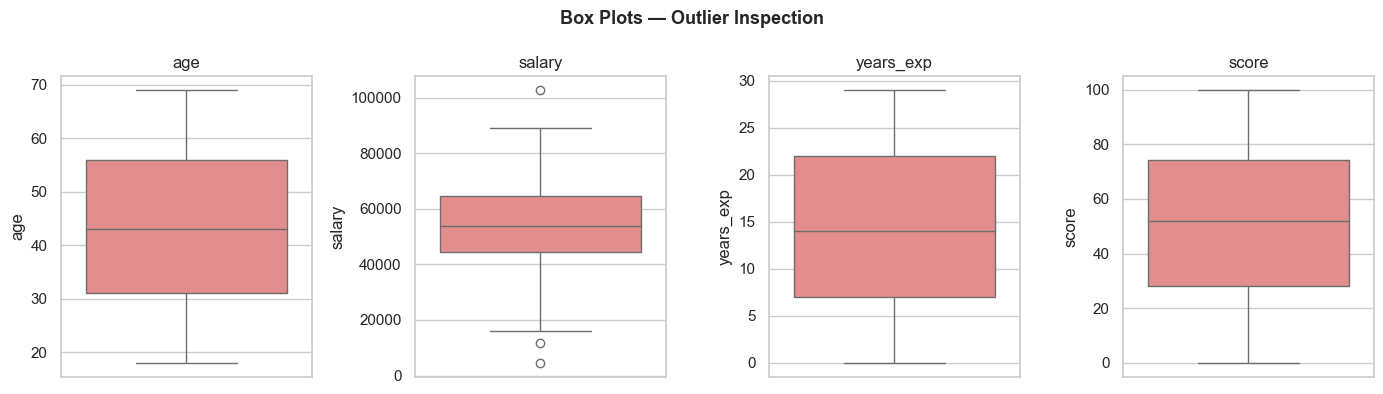

In [10]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(14, 4))
fig.suptitle("Box Plots — Outlier Inspection", fontsize=13, fontweight="bold")

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color="lightcoral")
    ax.set_title(col)

plt.tight_layout()
plt.show()

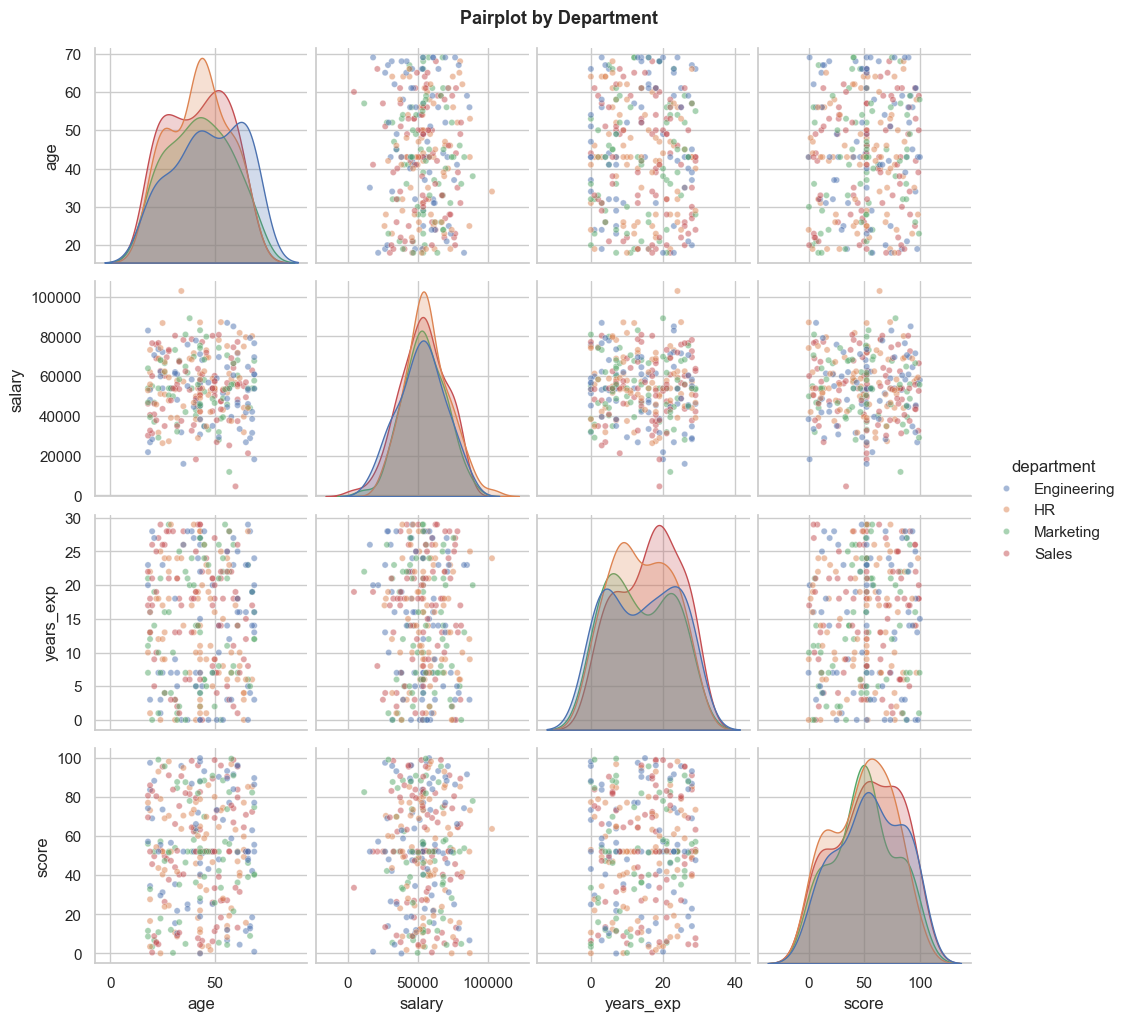

In [11]:
pair_grid = sns.pairplot(
    df_clean[numeric_cols + ["department"]],
    hue="department",
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20},
)
pair_grid.fig.suptitle("Pairplot by Department", y=1.02, fontsize=13, fontweight="bold")
plt.show()

## 6. Scikit-learn Pipeline with XGBoost

Predict **department** (4-class) from `age`, `salary`, `years_exp`, `score`, and `gender`.

Pipeline steps:
- **Numeric features** → `SimpleImputer` (median) → `StandardScaler`
- **Categorical features** → `SimpleImputer` (most frequent) → `OneHotEncoder`
- **Classifier** → `XGBClassifier`

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# Re-load raw CSV so the pipeline handles imputation itself
df_ml = pd.read_csv("sample_dataset.csv").drop_duplicates()

X = df_ml[["age", "salary", "years_exp", "score", "gender"]]
y = df_ml["department"]

# Encode target labels to integers (XGBoost requirement)
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Classes:", le.classes_)

Train: (240, 5), Test: (60, 5)
Classes: ['Engineering' 'HR' 'Marketing' 'Sales']


In [13]:
numeric_features = ["age", "salary", "years_exp", "score"]
categorical_features = ["gender"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=42,
    )),
])

pipeline.fit(X_train, y_train)
print("Pipeline trained.")

C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Pipeline trained.


In [14]:
# Cross-validation on training set
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"5-fold CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Test set evaluation
y_pred = pipeline.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\s

5-fold CV accuracy: 0.225 ± 0.066

Classification Report:
              precision    recall  f1-score   support

 Engineering       0.22      0.29      0.25        14
          HR       0.33      0.31      0.32        16
   Marketing       0.25      0.21      0.23        14
       Sales       0.27      0.25      0.26        16

    accuracy                           0.27        60
   macro avg       0.27      0.27      0.27        60
weighted avg       0.27      0.27      0.27        60



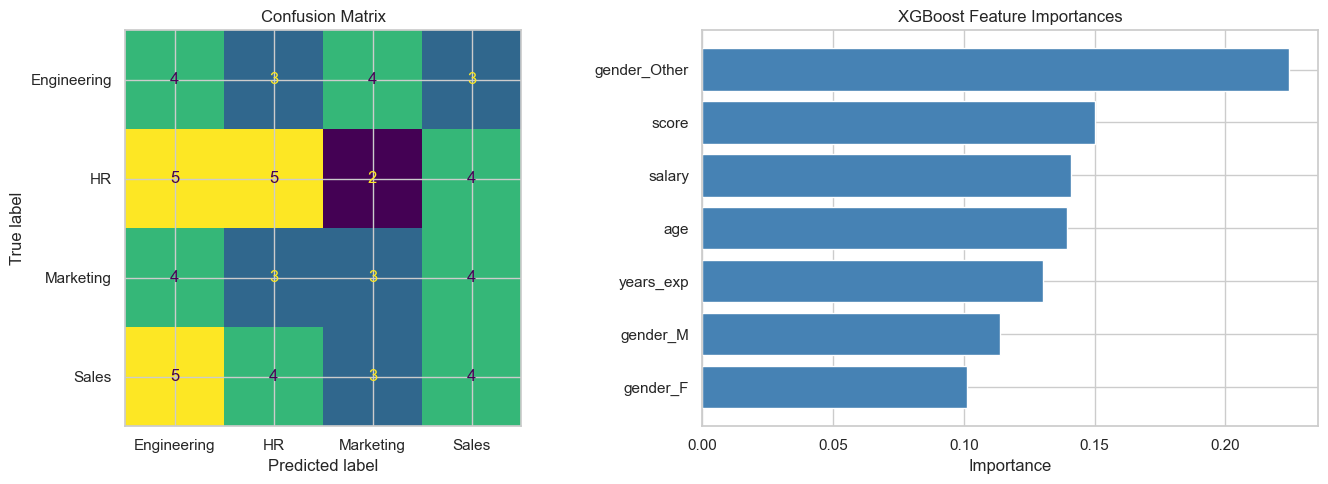

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=le.classes_, ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix")

# Feature importances
feature_names = (
    numeric_features
    + list(pipeline.named_steps["preprocessor"]
           .named_transformers_["cat"]
           .named_steps["encoder"]
           .get_feature_names_out(categorical_features))
)
importances = pipeline.named_steps["classifier"].feature_importances_
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=True)
)
axes[1].barh(importance_df["feature"], importance_df["importance"], color="steelblue")
axes[1].set_title("XGBoost Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 7. Cross-Validation & ROC / PR Curves

Detailed cross-validation across multiple metrics, then per-class ROC and Precision-Recall curves using a one-vs-rest strategy.

In [16]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"],
    return_train_score=True,
)

metrics = ["accuracy", "f1_macro", "f1_weighted", "roc_auc_ovr_weighted"]
rows = []
for m in metrics:
    rows.append({
        "metric":       m,
        "train_mean":   cv_results[f"train_{m}"].mean(),
        "train_std":    cv_results[f"train_{m}"].std(),
        "val_mean":     cv_results[f"test_{m}"].mean(),
        "val_std":      cv_results[f"test_{m}"].std(),
    })

cv_df = pd.DataFrame(rows).set_index("metric").round(4)
print("5-Fold Cross-Validation Results")
cv_df

C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_scorer.py", line 166, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Pyth

5-Fold Cross-Validation Results


C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_scorer.py", line 166, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "C:\Users\stats\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metr

,train_mean,train_std,val_mean,val_std
metric,,,,
accuracy,1.0,0.0,0.2458,0.0243
f1_macro,1.0,0.0,0.2371,0.0312
f1_weighted,1.0,0.0,0.2401,0.0272
roc_auc_ovr_weighted,NaN,NaN,NaN,NaN


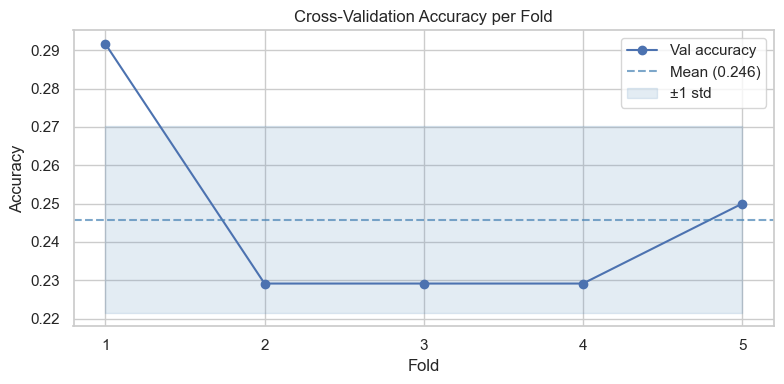

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

fold_accuracy = cv_results["test_accuracy"]
ax.plot(range(1, 6), fold_accuracy, marker="o", label="Val accuracy")
ax.axhline(fold_accuracy.mean(), linestyle="--", color="steelblue", alpha=0.7, label=f"Mean ({fold_accuracy.mean():.3f})")
ax.fill_between(
    range(1, 6),
    fold_accuracy.mean() - fold_accuracy.std(),
    fold_accuracy.mean() + fold_accuracy.std(),
    alpha=0.15, color="steelblue", label="±1 std"
)
ax.set_xticks(range(1, 6))
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("Cross-Validation Accuracy per Fold")
ax.legend()
plt.tight_layout()
plt.show()

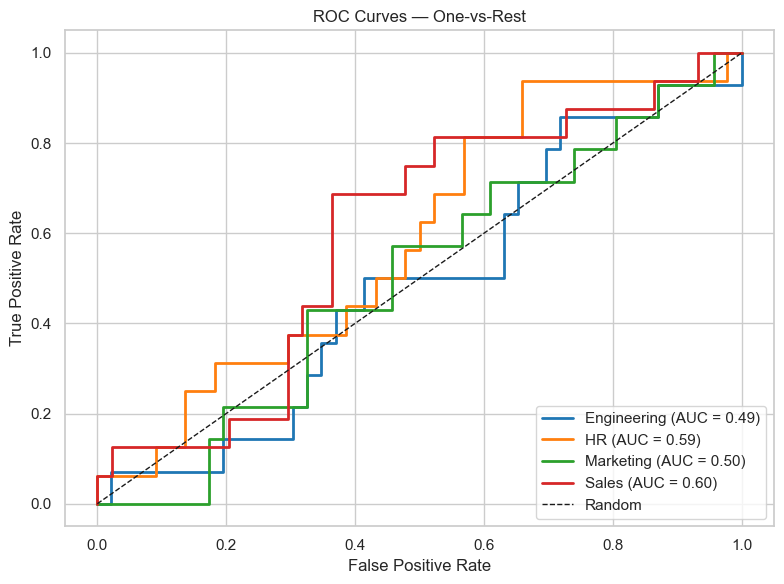

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Probability scores for all classes
y_prob = pipeline.predict_proba(X_test)

# Binarize test labels for OvR
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10.colors

for i, cls_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], lw=2, label=f"{cls_name} (AUC = {roc_auc:.2f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — One-vs-Rest")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

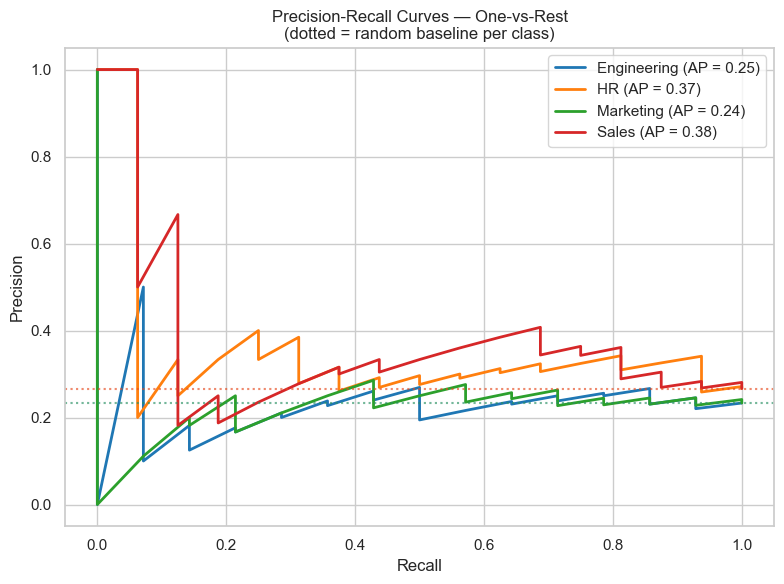

In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

for i, cls_name in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_prob[:, i])
    ax.plot(recall, precision, color=colors[i], lw=2, label=f"{cls_name} (AP = {ap:.2f})")

baseline = y_test_bin.mean(axis=0)
for i, b in enumerate(baseline):
    ax.axhline(b, color=colors[i], linestyle=":", alpha=0.4)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — One-vs-Rest\n(dotted = random baseline per class)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()